In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load dataset
df = pd.read_csv("haberman.csv")

# Display first rows
df.head()

,30,64,1,1.1
0,30,62,3,1
1,30,65,0,1
2,31,59,2,1
3,31,65,4,1
4,33,58,10,1


In [3]:
df.columns = ["age", "year_of_operation", "positive_axillary_nodes", "survival_status"]

df.head()

,age,year_of_operation,positive_axillary_nodes,survival_status
0,30,62,3,1
1,30,65,0,1
2,31,59,2,1
3,31,65,4,1
4,33,58,10,1


In [4]:
print(df.info())
print(df.describe())

# Check class distribution
print(df["survival_status"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   age                      305 non-null    int64
 1   year_of_operation        305 non-null    int64
 2   positive_axillary_nodes  305 non-null    int64
 3   survival_status          305 non-null    int64
dtypes: int64(4)
memory usage: 9.7 KB
None
              age  year_of_operation  positive_axillary_nodes  survival_status
count  305.000000         305.000000               305.000000       305.000000
mean    52.531148          62.849180                 4.036066         1.265574
std     10.744024           3.254078                 7.199370         0.442364
min     30.000000          58.000000                 0.000000         1.000000
25%     44.000000          60.000000                 0.000000         1.000000
50%     52.000000          63.000000                 1.000000         1.000000

In [5]:
# In Haberman dataset:
# 1 = survived 5+ years
# 2 = died within 5 years

df["survival_status"] = df["survival_status"].map({1: 1, 2: 0})

In [6]:
X = df.drop("survival_status", axis=1)
y = df["survival_status"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7377049180327869

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.38      0.43        16
           1       0.80      0.87      0.83        45

    accuracy                           0.74        61
   macro avg       0.65      0.62      0.63        61
weighted avg       0.72      0.74      0.72        61



In [9]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7868852459016393

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.25      0.38        16
           1       0.79      0.98      0.87        45

    accuracy                           0.79        61
   macro avg       0.79      0.61      0.63        61
weighted avg       0.79      0.79      0.74        61



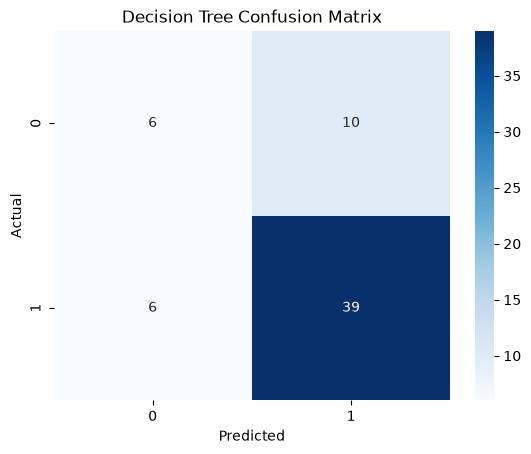

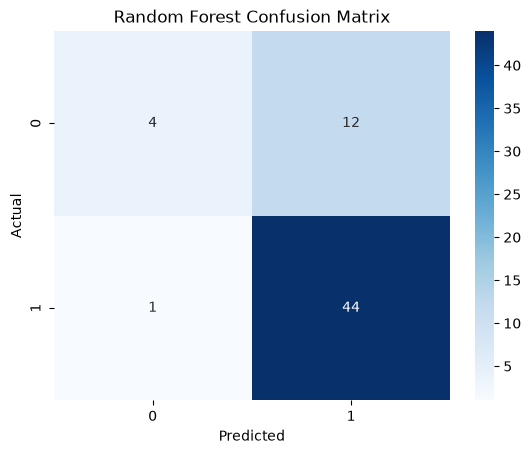

In [10]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(y_test, y_pred_dt, "Decision Tree Confusion Matrix")
plot_cm(y_test, y_pred_rf, "Random Forest Confusion Matrix")